In [4]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
np.random.seed(42)
torch.manual_seed(42)
file_path = "../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
def preprocesss(file_path,seq_len=50):
    dat = np.load(file_path)[:,4000:8000,:] 
    data = dat.transpose(1, 0, 2)  
    point_mask = np.ones(55, dtype=bool)
    point_mask[[26,53]] = False
    data = data[:, point_mask, :]  # Now (timesteps, 53, 3)
    
    # Invert Z-axis (matching original processing)
    data[..., 2] *= -1
    data = data.reshape(data.shape[0]//seq_len, seq_len, 53*3)
    data = torch.tensor(data,dtype=torch.float)
    return data
data=preprocesss(file_path)
data.shape

torch.Size([80, 50, 159])

In [6]:
class MotionAutoencoder(nn.Module):
    def __init__(self, seq_len=40, input_dim=159, latent_dim=64):
        super(MotionAutoencoder, self).__init__()
        
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(seq_len * input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, seq_len * input_dim)
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        reconstruction = reconstruction.reshape(batch_size, self.seq_len, self.input_dim)
        
        return reconstruction, z
    
    def encode(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        return self.encoder(x)
    
    def decode(self, z):
        batch_size = z.shape[0]
        reconstruction = self.decoder(z)
        return reconstruction.reshape(batch_size, self.seq_len, self.input_dim)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def get_embeddings(model, data):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32).to(device)
        embeddings = model.encode(data_tensor).cpu().numpy()
    
    return embeddings


def augment_data(data, num_augmentations=5):
    augmented_data = []
    augmented_labels = []
    
    for i, (sequence, label) in enumerate(data):
        augmented_data.append(sequence)
        augmented_labels.append(label)
        
        for j in range(num_augmentations):
            # Time warping (slight stretching/compressing)
            time_factor = np.random.uniform(0.9, 1.1)
            warped = np.zeros_like(sequence)
            for t in range(sequence.shape[0]):
                src_t = min(int(t * time_factor), sequence.shape[0] - 1)
                warped[t] = sequence[src_t]
            
            # Slight random noise
            noise = np.random.normal(0, 0.02, sequence.shape)
            augmented = warped + noise
            
            augmented_data.append(augmented)
            augmented_labels.append(label)
    
    return np.array(augmented_data), np.array(augmented_labels)


def semi_supervised_labeling(dance_sequences, manual_labels):


    print(f"Total sequences: {len(dance_sequences)}")
    print(f"Manually labeled: {len(manual_labels)}")
    
    # 1. Train autoencoder on all sequences
    model = MotionAutoencoder(seq_len=dance_sequences.shape[1], input_dim=dance_sequences.shape[2], latent_dim=64)
    model.load_state_dict(torch.load('models/best_autoencoder.pth'))
    print("Best model loaded.")
    trained_model = model 
    
    # 2. Get embeddings for all sequences
    embeddings = get_embeddings(trained_model, dance_sequences)
    print(f"Embedding shape: {embeddings.shape}")
    
    # 3. Prepare labeled data
    labeled_indices = list(range(len(manual_labels)))
    labeled_embeddings = embeddings[labeled_indices]
    
    # 4. Augment the labeled data to improve diversity
    labeled_sequences = [(dance_sequences[i], manual_labels[i]) for i in labeled_indices]
    augmented_sequences, augmented_labels = augment_data(labeled_sequences)
    
    print(f"Augmented labeled sequences: {len(augmented_sequences)}")
    
    # 5. Get embeddings for augmented data
    augmented_embeddings = get_embeddings(trained_model, augmented_sequences)
    
    # 6. Train a KNN classifier on augmented labeled data
    knn = KNeighborsClassifier(n_neighbors=2, weights='distance',algorithm='kd_tree')
    knn.fit(augmented_embeddings, augmented_labels)
    
    # 7. Predict labels for unlabeled sequences
    unlabeled_indices = list(range(len(manual_labels), len(dance_sequences)))
    unlabeled_embeddings = embeddings[unlabeled_indices]
    
    predicted_labels = knn.predict(unlabeled_embeddings)
    
    # 8. Combine manual and predicted labels
    all_labels = manual_labels + predicted_labels.tolist()
    
    # 9. Visualize the embeddings with labels
    tsne = TSNE(n_components=2, random_state=42,method='exact',n_jobs=1)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 10))
    unique_labels = set(all_labels)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    color_map = dict(zip(unique_labels, colors))
    
    # Plot manually labeled points with bold outline
    for i in labeled_indices:
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                   color=color_map[all_labels[i]], 
                   s=100, edgecolors='black', linewidths=2)
    
    # Plot auto-labeled points
    for i in unlabeled_indices:
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                   color=color_map[all_labels[i]], 
                   s=50, alpha=0.7)
    
    # Add legend
    for label, color in zip(unique_labels, colors):
        plt.scatter([], [], color=color, label=label)
    plt.legend()
    
    plt.title("t-SNE visualization of dance sequence embeddings")
    plt.savefig("dance_embeddings_tsne_visualization_with_labels.png")
    plt.show()
    plt.close()
    
    # 10. Calculate confidence scores for the predictions
    unlabeled_proba = knn.predict_proba(unlabeled_embeddings)
    confidence_scores = np.max(unlabeled_proba, axis=1)
    
    # Print confidence statistics
    avg_confidence = np.mean(confidence_scores)
    low_confidence_count = np.sum(confidence_scores < 0.7)
    
    print(f"Average prediction confidence: {avg_confidence:.2f}")
    print(f"Number of low confidence predictions (<0.7): {low_confidence_count}")
    
    # Return all labels and confidence scores for manual review
    return all_labels, confidence_scores

Total sequences: 80
Manually labeled: 10
Best model loaded.
Embedding shape: (80, 64)
Augmented labeled sequences: 60


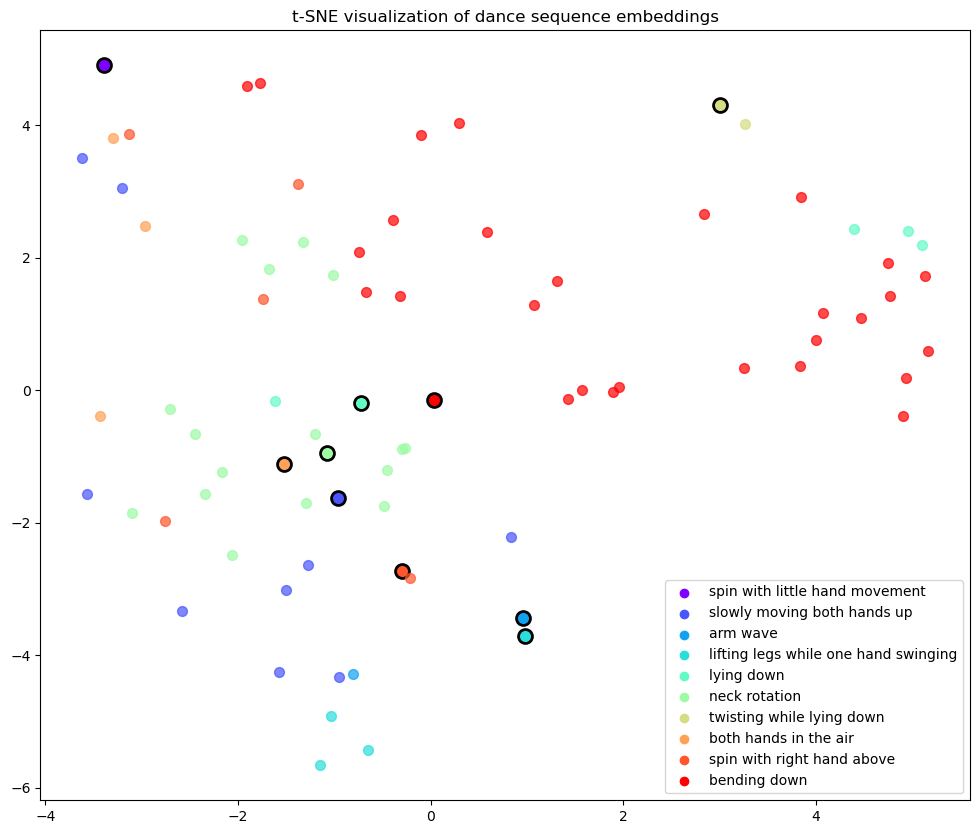

Average prediction confidence: 0.99
Number of low confidence predictions (<0.7): 1


In [10]:
dance_sequences = data
manual_labels = [
    "spin with little hand movement", "spin with right hand above", "lifting legs while one hand swinging", "arm wave", "slowly moving both hands up",
    "both hands in the air", "bending down", "neck rotation", "lying down", "twisting while lying down"
]

all_labels, confidence_scores = semi_supervised_labeling(
    dance_sequences, manual_labels
)

In [11]:
# Display results for first few sequences
print("\nLabeling Results:")
print("Sequence | Label | Confidence")
print("--------------------------")

for i in range(20):  # Show first 20 as example
    confidence = confidence_scores[i - len(manual_labels)] if i >= len(manual_labels) else 1.0
    confidence_str = f"{confidence:.2f}" if i >= len(manual_labels) else "Manual"
    print(f"{i:8d} | {all_labels[i]:10s} | {confidence_str}")


Labeling Results:
Sequence | Label | Confidence
--------------------------
       0 | spin with little hand movement | Manual
       1 | spin with right hand above | Manual
       2 | lifting legs while one hand swinging | Manual
       3 | arm wave   | Manual
       4 | slowly moving both hands up | Manual
       5 | both hands in the air | Manual
       6 | bending down | Manual
       7 | neck rotation | Manual
       8 | lying down | Manual
       9 | twisting while lying down | Manual
      10 | twisting while lying down | 1.00
      11 | spin with right hand above | 1.00
      12 | neck rotation | 1.00
      13 | neck rotation | 1.00
      14 | slowly moving both hands up | 1.00
      15 | both hands in the air | 1.00
      16 | slowly moving both hands up | 1.00
      17 | spin with right hand above | 1.00
      18 | neck rotation | 1.00
      19 | neck rotation | 1.00


# now lets visualize one to see how the labelling went

In [22]:
#labels and skeleton connections (from original code)
point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',)) # added 
]
# from pirounet paper simpler representation
skeleton_lines2 = [
    #     ( (start group), (end group) ),
    (("LHEL",), ("LTOE",)),  # toe to heel
    (("RHEL",), ("RTOE",)),
    (("LKNE", "LKNI"), ("LHEL",)),  # heel to knee
    (("RKNE", "RKNI"), ("RHEL",)),
    (("LKNE", "LKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),  # knee to "navel"
    (("RKNE", "RKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),
    (
        ("LFWT", "RFWT", "LBWT", "RBWT"),
        (
            "STRN",
            "T10",
        ),
    ),  # "navel" to chest
    (
        (
            "STRN",
            "T10",
        ),
        (
            "CLAV",
            "C7",
        ),
    ),  # chest to neck
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "LFSH",
            "LBSH",
        ),
    ),  # neck to shoulders
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "RFSH",
            "RBSH",
        ),
    ),
    (
        (
            "LFSH",
            "LBSH",
        ),
        (
            "LELB",
            "LIEL",
        ),
    ),  # shoulders to elbows
    (
        (
            "RFSH",
            "RBSH",
        ),
        (
            "RELB",
            "RIEL",
        ),
    ),
    (
        (
            "LELB",
            "LIEL",
        ),
        (
            "LOWR",
            "LIWR",
        ),
    ),  # elbows to wrist
    (
        (
            "RELB",
            "RIEL",
        ),
        (
            "ROWR",
            "RIWR",
        ),
    ),
    (("LFHD",), ("LBHD",)),  # draw lines around circumference of the head
    (("LBHD",), ("RBHD",)),
    (("RBHD",), ("RFHD",)),
    (("RFHD",), ("LFHD",)),
    (("LFHD",), ("ARIEL",)),  # connect circumference points to top of head
    (("LBHD",), ("ARIEL",)),
    (("RBHD",), ("ARIEL",)),
    (("RFHD",), ("ARIEL",)),
]

reduced_joint_names = [
    'ARIEL', 'C7', 'CLAV', 'STRN',  # Head & Spine
    'RFSH', 'LFSH', 'RBSH', 'LBSH',  # Shoulders
    'RIEL', 'LIEL', 'RIWR', 'LIWR',  # Elbows & Wrists
    'RKNE', 'LKNE', 'RTOE', 'LTOE',  # Knees & Toes
    'RHEL', 'LHEL',  # Heels
    'RFWT', 'LFWT', 'RBWT', 'LBWT',  # Hip/Pelvis
    'RTHI', 'LTHI', 'RSHN', 'LSHN'  # Thighs & Shins
]
def create_skeleton(points, labels, connections, show_points=True, reduced_joint_names=None):
    label_to_idx = {label: i for i, label in enumerate(labels)}
    valid_indices = (np.arange(len(labels)) if reduced_joint_names is None 
                     else np.array([label_to_idx[j] for j in reduced_joint_names if j in label_to_idx]))
    if len(valid_indices) < 2:
        raise ValueError("At least two valid joints are needed.")
    
    index_map = {old: new for new, old in enumerate(valid_indices)}
    
    lines = np.hstack([[2, index_map[s], index_map[e]] 
                      for a, b in connections 
                      if (s := label_to_idx.get(a[0])) in index_map 
                      and (e := label_to_idx.get(b[0])) in index_map]).astype(np.int32)
    
    mesh = pv.PolyData(np.asarray(points)[valid_indices])
    if lines.size > 0:
        mesh.lines = lines
    
    return mesh, 10 if show_points else 0
def create_skeleton2(points, show_points=True): #for face triangle colour
    points = np.array(points)
    if points.shape[1] != 3 or len(points) < 2:
        raise ValueError("Points must have shape (N,3) with at least two points.")
    lines = np.array([(2, i, i + 1) for i in range(len(points) - 1)], dtype=np.int32).flatten()
    if len(points) == 3:
        lines = np.append(lines, [2, 2, 0])

    mesh = pv.PolyData(points)
    if lines.size > 0:
        mesh.lines = lines

    return mesh, 10 if show_points else 0
import os
import numpy as np
import cv2
import pyvista as pv
import imageio.v2 as iio
from tqdm import tqdm

def generate_skeleton_animation(data, output_name="skeleton_animation", stride=1, fps=24):
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  

    label_to_idx = {label: idx for idx, label in enumerate(point_labels)}
    head_indices = np.array([0, 8, 33])  

    all_points = data.reshape(-1, data.shape[-1])
    global_min = all_points.min(axis=0)
    global_max = all_points.max(axis=0)
    global_center = (global_min + global_max) / 2
    global_diagonal = np.linalg.norm(global_max - global_min)
    global_view_distance = global_diagonal * 1.5

    camera_position = [
        global_center[0] + global_view_distance * 0.5,
        global_center[1] + global_view_distance * 0.3,
        global_center[2] + global_view_distance * 0.4
    ]

    plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
    plotter.reset_camera()
    plotter.camera.zoom(2.0) 
    prev_frame = data[0]
    start_saving = False  
    movement_threshold = 0.001 * global_diagonal  
    total_frames = min(data.shape[0], 1500)  

    output_gif = f"{output_name}.gif"
    output_mp4 = f"{output_name}.mp4"

    with iio.get_writer(output_gif, mode="I", duration=int(1000 / fps)) as gif_writer:
        video_writer = None

        for t in tqdm(range(0, total_frames, stride)):
            current_frame = data[t]
            movement = np.linalg.norm(current_frame - prev_frame)

            if movement > movement_threshold or t > 0:
                start_saving = True 

            if start_saving:
                frame_center = current_frame.mean(axis=0)
                camera_position = [
                    frame_center[0] + global_view_distance * 0.5,
                    frame_center[1] + global_view_distance * 0.3,
                    frame_center[2] + global_view_distance * 0.4
                ]
                plotter.camera_position = [camera_position, frame_center, [0, 0, 1]]

                mesh, point_size = create_skeleton(current_frame, point_labels, skeleton_lines, show_points=True)
                mesh2, point_size2 = create_skeleton2(current_frame[head_indices], show_points=True)
                # point_size=0
                # point_size2=0
                plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, point_size=point_size/1.25 , color='black')
                plotter.add_mesh(mesh2, render_lines_as_tubes=True, line_width=3, point_size=point_size2 * 1.1, color='red')

                img = plotter.screenshot(return_img=True)
                frame = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)

                gif_writer.append_data(frame)

                if video_writer is None:
                    height, width, _ = frame.shape
                    video_writer = cv2.VideoWriter(output_mp4, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

                video_writer.write(frame)
                plotter.clear_actors()

            prev_frame = current_frame  

            if t % 100 == 0:
                plotter.close()
                del plotter
                plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  
                plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
                plotter.camera.zoom(0.50) 

        if video_writer:
            video_writer.release()

    plotter.close()
    del plotter  

    print(f"Saved {output_gif} and {output_mp4}")
def visualize(one_seq,filename='temppp'):
    path = os.path.join("animate", f"{filename}")
    inp = np.array(one_seq.detach().reshape(one_seq.shape[0],53,3))
    # print(inp.shape)
    generate_skeleton_animation(inp,output_name=path)

In [24]:
idx=17
da = data[idx,:,:]
visualize(da,filename='validating_label')

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 81.93it/s]


Saved animate/validating_label.gif and animate/validating_label.mp4


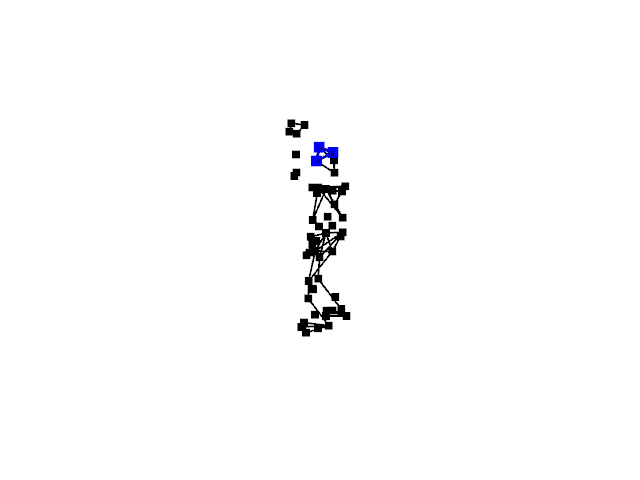

In [26]:
from IPython.display import Image
Image(filename='animate/validating_label.gif')

In [30]:
all_labels[idx] #label after using the semi-supervised learning

'spin with right hand above'

### in this notebook the labelling is done with the help of knn the result is okayish but not too good because of my labelling but is someone professional labelled it would definatelty be better 

In [33]:
all_labels

['spin with little hand movement',
 'spin with right hand above',
 'lifting legs while one hand swinging',
 'arm wave',
 'slowly moving both hands up',
 'both hands in the air',
 'bending down',
 'neck rotation',
 'lying down',
 'twisting while lying down',
 'twisting while lying down',
 'spin with right hand above',
 'neck rotation',
 'neck rotation',
 'slowly moving both hands up',
 'both hands in the air',
 'slowly moving both hands up',
 'spin with right hand above',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'both hands in the air',
 'spin with right hand above',
 'neck rotation',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'lying down',
 'lying down',
 'bending down',
 'bending down',
 'lying down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bendin